In [1]:

import pandas as pd

df = pd.read_csv("C:/Rhushi/Padhai/power bi/Product Funnel/dataset/2019-Oct.csv")

df.head()


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [2]:
df.shape

(42448764, 9)

In [3]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.8 GB


In [5]:
df['event_type'].value_counts()

event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

In [6]:

cols = [
    'event_time',
    'event_type',
    'product_id',
    'category_code',
    'brand',
    'price',
    'user_id',
    'user_session'
]

df = pd.read_csv("../dataset/2019-Oct.csv", usecols=cols)

In [7]:
df_sample = df.sample(n=1000000, random_state=42)  #random_state is used to ensure reproducibility of the sample (same sample is generated each time the code is run)
df_sample.to_csv("../dataset/ecommerce_sample.csv", index=False)

In [8]:
df = pd.read_csv("../dataset/ecommerce_sample.csv")

df.head()

,event_time,event_type,product_id,category_code,brand,price,user_id,user_session
0,2019-10-09 02:46:19 UTC,view,29900078,NaN,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa
1,2019-10-21 16:17:11 UTC,view,1801805,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e
2,2019-10-21 14:42:20 UTC,cart,1004870,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3
3,2019-10-03 18:40:22 UTC,view,5701087,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c
4,2019-10-19 08:58:51 UTC,view,5300097,NaN,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b


In [9]:
df.shape
(df['event_type'].value_counts(normalize=True) * 100).round(2)  #normalize=True is used to get the percentage of each event type in the dataset, and round(2) is used to round the percentages to 2 decimal places for better readability.

event_type
view        96.04
cart         2.19
purchase     1.77
Name: proportion, dtype: float64

Store user counts of each event


In [10]:
view_users = df[df['event_type'] == 'view']['user_id'].nunique()
cart_users = df[df['event_type'] == 'cart']['user_id'].nunique()
purchase_users = df[df['event_type'] == 'purchase']['user_id'].nunique()
print(f"Number of users who viewed a product: {view_users}")
print(f"Number of users who added a product to cart: {cart_users}")
print(f"Number of users who made a purchase: {purchase_users}")

Number of users who viewed a product: 586694
Number of users who added a product to cart: 20259
Number of users who made a purchase: 16538


Calculate conversion rates

In [11]:
view_to_cart = (cart_users / view_users) * 100
cart_to_purchase = (purchase_users / cart_users) * 100
view_to_purchase = (purchase_users / view_users) * 100

DISPLAY RESULTS


In [12]:
print("View → Cart Conversion:", round(view_to_cart,2), "%")
print("Cart → Purchase Conversion:", round(cart_to_purchase,2), "%")
print("Overall View → Purchase Conversion:", round(view_to_purchase,2), "%")

View → Cart Conversion: 3.45 %
Cart → Purchase Conversion: 81.63 %
Overall View → Purchase Conversion: 2.82 %


So far we analyzed the overall funnel:

View → Cart → Purchase

But companies rarely stop there. Product teams want to know:

• Which categories convert the best
• Which categories have the highest drop-off
• Which products drive revenue

Example business question:

“Do electronics convert worse than clothing?”

If one category has low conversion, the company might:

change pricing

improve product descriptions

offer discounts

So we analyze funnel behaviour by category.

In [ ]:
#Count events by category
category_events = df.groupby(['category_code','event_type']).size().unstack() #groupby is used to group the data by category_code and event_type, size() is used to count the number of occurrences of each combination of category_code and event_type, and unstack() is used to pivot the event_type from rows to columns for better readability.

category_events.head()

event_type,cart,purchase,view
category_code,,,
accessories.bag,15.0,30.0,4455.0
accessories.umbrella,NaN,1.0,81.0
accessories.wallet,NaN,6.0,1042.0
apparel.belt,NaN,NaN,51.0
apparel.costume,NaN,14.0,3206.0


In [14]:
category_events = category_events.fillna(0)

In [15]:
category_events = category_events.sort_values(by='purchase', ascending=False)

category_events.head(10)

event_type,cart,purchase,view
category_code,,,
electronics.smartphone,12925.0,8031.0,250406.0
electronics.audio.headphone,1267.0,691.0,23991.0
electronics.video.tv,868.0,510.0,24799.0
electronics.clocks,454.0,428.0,30193.0
appliances.kitchen.washer,504.0,383.0,19675.0
computers.notebook,416.0,379.0,26173.0
appliances.environment.vacuum,375.0,306.0,18060.0
appliances.kitchen.refrigerators,294.0,282.0,20421.0
electronics.tablet,203.0,127.0,7155.0


Time-Based User Behavior Analysis

In [16]:
df['event_time'] = pd.to_datetime(df['event_time']) #convert the event_time column to datetime format for easier manipulation and analysis of time-based data.

In [17]:
df['hour'] = df['event_time'].dt.hour #extract the hour from the event_time column to analyze user activity patterns throughout the day.

In [18]:
hourly_purchases = df[df['event_type']=='purchase'].groupby('hour').size() #filter the dataset to include only purchase events, group the data by hour, and count the number of purchases for each hour to analyze the distribution of purchases throughout the day.

hourly_purchases

hour
0       75
1      143
2      305
3      672
4     1002
5     1121
6     1258
7     1238
8     1290
9     1299
10    1300
11    1135
12    1035
13     912
14     856
15     899
16     863
17     759
18     614
19     401
20     234
21     133
22      90
23      70
dtype: int64

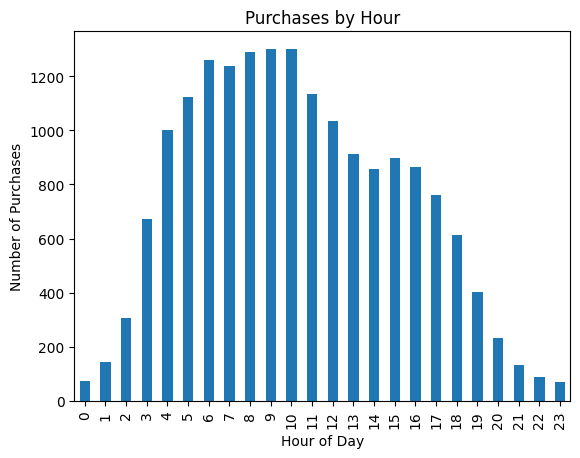

In [19]:
import matplotlib.pyplot as plt

hourly_purchases.plot(kind='bar')

plt.title("Purchases by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Purchases")

plt.show()

Revenue Analysis

In [23]:
purchases = df[df['event_type'] == 'purchase']
total_revenue = purchases['price'].sum()

print(f"Total Revenue: {total_revenue:,.2f}")



Total Revenue: 5,398,836.05


Prepare Clean Analytics Tables for Dashboard & SQL

In [24]:
funnel_metrics = pd.DataFrame({
    "Stage": ["View", "Cart", "Purchase"],
    "Users": [view_users, cart_users, purchase_users]
})

funnel_metrics

,Stage,Users
0,View,586694
1,Cart,20259
2,Purchase,16538


In [25]:
category_metrics = df.groupby(['category_code','event_type']).size().unstack().fillna(0)

category_metrics.head()

event_type,cart,purchase,view
category_code,,,
accessories.bag,15.0,30.0,4455.0
accessories.umbrella,0.0,1.0,81.0
accessories.wallet,0.0,6.0,1042.0
apparel.belt,0.0,0.0,51.0
apparel.costume,0.0,14.0,3206.0


In [26]:
revenue_metrics = purchases.groupby('category_code')['price'].sum().reset_index()

revenue_metrics.head()

,category_code,price
0,accessories.bag,1133.11
1,accessories.umbrella,25.48
2,accessories.wallet,231.65
3,apparel.costume,1497.98
4,apparel.jeans,40.67


In [27]:
time_metrics = df.groupby('hour')['event_type'].count().reset_index()

time_metrics.head()

,hour,event_type
0,0,7178
1,1,13096
2,2,25131
3,3,36384
4,4,45083


In [28]:
funnel_metrics.to_csv("../dataset/funnel_metrics.csv", index=False)

category_metrics.to_csv("../dataset/category_metrics.csv")

revenue_metrics.to_csv("../dataset/revenue_metrics.csv", index=False)

time_metrics.to_csv("../dataset/time_metrics.csv", index=False)